In [8]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import norm

rng = np.random.default_rng(42)

## Proximal gradient and accelerated proximal gradient 


In [9]:
def pg(x0, grad_f, prox_g, F, alpha, max_iter=1000):
    x = x0.copy()
    obj = [F(x)]
    for _ in range(max_iter):
        x = prox_g(x - alpha * grad_f(x), alpha)
        obj.append(F(x))
    return x, np.array(obj)

#FISTA
def apg(x0, grad_f, prox_g, F, alpha, max_iter=1000):
    """
    Update rules:
        x^{k+1} = prox_{alpha g}(y^k - alpha * grad_f(y^k))
        t_{k+1}  = (1 + sqrt(1 + 4 t_k^2)) / 2
        y^{k+1}  = x^{k+1} + (t_k - 1)/t_{k+1} * (x^{k+1} - x^k)
    """
    x = x0.copy()
    y = x0.copy()
    t = 1.0
    obj = [F(x)]
    for _ in range(max_iter):
        x_new = prox_g(y - alpha * grad_f(y), alpha)
        t_new = (1 + np.sqrt(1 + 4 * t**2)) / 2
        y = x_new + (t - 1) / t_new * (x_new - x)
        x, t = x_new, t_new
        obj.append(F(x))
    return x, np.array(obj)

## Douglas-Rachford Splitting (DRS)

Solves LASSO by treating **both terms as non-smooth** (no gradient of $f$ required):
$$g_1(x) = \tfrac{1}{2}\|Ax-b\|^2 \qquad g_2(x) = \lambda\|x\|_1$$

**Iteration** (fixed-point on the auxiliary variable $z$):
$$x^{k+1} = \operatorname{prox}_{\alpha g_1}(z^k), \quad
u^{k+1} = \operatorname{prox}_{\alpha g_2}(2x^{k+1} - z^k), \quad
z^{k+1} = z^k + u^{k+1} - x^{k+1}$$

**Stable prox of $g_1$** (via $m{\times}m$ system, cheaper than $n{\times}n$ when $m < n$):
$$\operatorname{prox}_{\alpha g_1}(v) = v + \alpha A^\top(I + \alpha AA^\top)^{-1}(b - Av)$$

In [ ]:
from scipy.linalg import cho_factor, cho_solve

def prox_g1_drs(v):
    s = cho_solve(_cho_m, b - A @ v)
    return v + alpha_drs * (A.T @ s)


def drs(z0, prox1, prox2, F, max_iter=1000):
    """DRS tracking the ergodic average — guaranteed O(1/k) in F."""
    z = z0.copy()
    x = prox1(z)
    x_sum = x.copy()
    obj = [F(x)]
    for k in range(max_iter):
        x = prox1(z)
        u = prox2(2 * x - z, alpha_drs)
        z = z + u - x
        x_sum = x_sum + x
        obj.append(F(x_sum / (k + 2)))
    return x, np.array(obj)

## Accelerated DRS

$$y^k = z^k + \beta_k(z^k - z^{k-1}), \qquad \beta_k = \frac{t_k - 1}{t_{k+1}}, \qquad t_{k+1} = \frac{1+\sqrt{1+4t_k^2}}{2}$$

Then run the standard DRS update from $y^k$:
$$x^{k+1} = \operatorname{prox}_{\alpha g_1}(y^k), \quad u^{k+1} = \operatorname{prox}_{\alpha g_2}(2x^{k+1} - y^k), \quad z^{k+1} = y^k + u^{k+1} - x^{k+1}$$

We again track the ergodic average for a fair comparison.  Whether ADRS achieves $O(1/k^2)$ in the fully non-smooth setting is the open question of this project.

In [ ]:
def adrs(z0, prox1, prox2, F, max_iter=1000):
    """Inertial DRS with Nesterov momentum on z, tracking the ergodic average."""
    z = z0.copy()
    z_prev = z0.copy()
    t = 1.0
    x = prox1(z)
    x_sum = x.copy()
    obj = [F(x)]
    for k in range(max_iter):
        t_new = (1 + np.sqrt(1 + 4 * t**2)) / 2
        beta = (t - 1) / t_new
        y = z + beta * (z - z_prev)
        x = prox1(y)
        u = prox2(2 * x - y, alpha_drs)
        z_prev = z
        z = y + u - x
        t = t_new
        x_sum = x_sum + x
        obj.append(F(x_sum / (k + 2)))
    return x, np.array(obj)

# LASSO

$$\min_x \; \frac{1}{2}\|Ax - b\|^2 + \lambda\|x\|_1$$

- $f(x) = \frac{1}{2}\|Ax-b\|^2 \Rightarrow \nabla f(x) = A^\top(Ax - b)$
- $g(x) = \lambda\|x\|_1 \Rightarrow \operatorname{prox}_{\alpha g}(v) = \operatorname{sign}(v)\max(|v| - \alpha\lambda,\, 0)$ 

In [89]:
m, n = 100, 200        
sparse = 20                   

A = rng.standard_normal((m, n))
x_true = np.zeros(n)
x_true[rng.choice(n, sparse, replace=False)] = rng.standard_normal(sparse)
b = A @ x_true + 0.01 * rng.standard_normal(m)

lam = 0.1 * norm(A.T @ b, np.inf)   # 10% of the lambda_max that zeros the solution
lam = 22

# Optimal step size for least squares is 1/L where L = ||A||^2 (Lipschitz constant of grad_f)
L = norm(A, ord=2) ** 2              
alpha = 1.0 / L                      #

# Choose alpha_drs = 1/sqrt(L): balances the two prox steps better than alpha=1
# when L >> lam (avoids extremely slow convergence from the ill-conditioned prox_g1 step).
alpha_drs = 1.0 / np.sqrt(L)
print(f"alpha_drs = {alpha_drs:.6f}  (= 1/sqrt(L),  prox_g2 threshold = {alpha_drs * lam:.4f})")

_cho_m = cho_factor(np.eye(m) + alpha_drs * (A @ A.T))


def grad_f(x):
    return A.T @ (A @ x - b)

def prox_g(v, a):
    return np.sign(v) * np.maximum(np.abs(v) - a * lam, 0.0)

def F(x):
    return 0.5 * norm(A @ x - b) ** 2 + lam * norm(x, 1)

x0 = np.zeros(n)
print(f"Problem: m={m}, n={n}, sparsity={sparse}, lambda={lam:.4f}, alpha={alpha:.6f}")

alpha_drs = 0.042799  (= 1/sqrt(L),  prox_g2 threshold = 0.9416)
Problem: m=100, n=200, sparsity=20, lambda=22.0000, alpha=0.001832


In [91]:
from scipy.optimize import minimize as sp_minimize

# Sove with an outside solver as a sanity check

def _qp_obj(z):
    u, v = z[:n], z[n:]
    r = A @ (u - v) - b
    g = A.T @ r
    val  = 0.5 * (r @ r) + lam * (u.sum() + v.sum())
    grad = np.concatenate([g + lam, -g + lam])
    return val, grad

res = sp_minimize(
    _qp_obj, np.zeros(2 * n), jac=True, method='L-BFGS-B',
    bounds=[(0, None)] * (2 * n),
    options={'ftol': 1e-15, 'gtol': 1e-12, 'maxiter': 50_000},
)
F_star_exact = F(res.x[:n] - res.x[n:])
print(f"Exact F* = {F_star_exact:.10f}  ({res.message})")

Exact F* = 390.4278422671  (CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH)


[ 3.25262219e-03  0.00000000e+00 -1.11022302e-16  2.77555756e-17
 -2.22044605e-16  1.38777878e-17  2.22044605e-16  5.55111512e-17
 -3.46944695e-17  1.11022302e-16  0.00000000e+00 -1.66533454e-16
 -2.25015597e-01  9.19059106e-02  1.66533454e-16 -2.22044605e-16
 -2.77555756e-16  6.24500451e-17  1.80411242e-16 -1.11022302e-16
  1.66533454e-16  1.42824054e+00  3.33066907e-16 -1.14491749e-16
  0.00000000e+00  0.00000000e+00  3.33066907e-16  1.66533454e-16
  2.22044605e-16  2.22044605e-16  3.33066907e-16 -3.33066907e-16
 -8.32667268e-17  2.77555756e-17  7.00292693e-01 -2.77555756e-17
 -2.22044605e-16 -1.11022302e-16 -3.33066907e-16  1.52246044e-02
 -6.93889390e-17 -1.66533454e-16  4.16333634e-17 -1.66533454e-16
 -1.11022302e-16 -1.38777878e-16  0.00000000e+00 -2.77555756e-17
 -1.11022302e-16 -1.14058069e-16 -1.81300795e+00  7.85630663e-04
  5.55111512e-17  1.66533454e-16  2.08166817e-16 -2.22044605e-16
  2.77555756e-17 -1.11022302e-16  0.00000000e+00  1.11022302e-16
  1.11022302e-16  2.77555

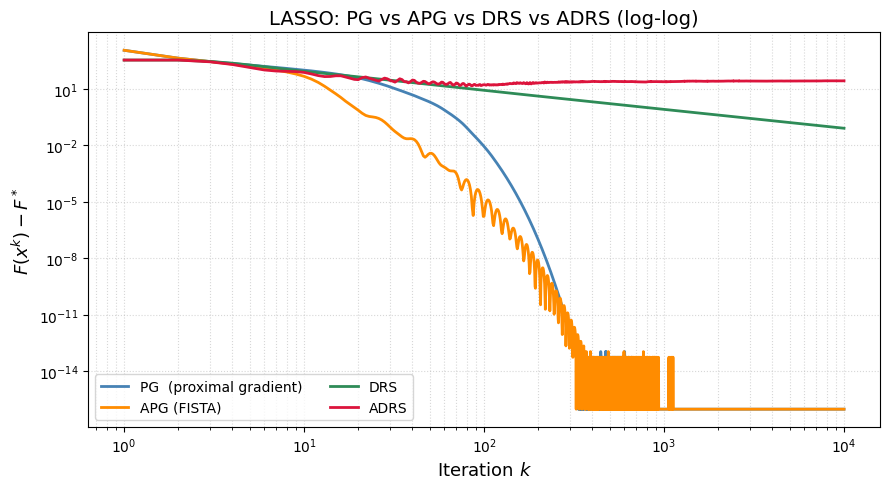

PG  (proximal gradient)         final gap = 0.00e+00
APG (FISTA)                     final gap = 0.00e+00
DRS                             final gap = 8.08e-02
ADRS                            final gap = 2.65e+01


In [92]:
MAX_ITER = 10000

_, obj_pg   = pg(x0,  grad_f, prox_g, F, alpha,    max_iter=MAX_ITER)
_, obj_apg  = apg(x0, grad_f, prox_g, F, alpha,    max_iter=MAX_ITER)
_, obj_drs  = drs(x0,  prox_g1_drs, prox_g, F, max_iter=MAX_ITER)
_, obj_adrs = adrs(x0, prox_g1_drs, prox_g, F, max_iter=MAX_ITER)

methods = [
    (obj_pg,   "PG  (proximal gradient)", "steelblue",  "-"),
    (obj_apg,  "APG (FISTA)",             "darkorange", "-"),
    (obj_drs,  "DRS",                     "seagreen",   "-"),
    (obj_adrs, "ADRS",         "crimson",    "-"),
]

F_star_exact = min(F_star_exact, obj_pg[-1], obj_apg[-1], obj_drs[-1], obj_adrs[-1])

k = np.arange(MAX_ITER + 1)

fig, ax = plt.subplots(figsize=(9, 5))
for obj, label, color, ls in methods:
    gap = obj - F_star_exact
    gap = np.maximum(gap, 1e-16)   # clip for log scale
    ax.loglog(k + 1, gap, ls=ls, color=color, lw=2, label=label)
ax.set_xlabel("Iteration $k$", fontsize=13)
ax.set_ylabel(r"$F(x^k) - F^*$", fontsize=13)
ax.set_title("LASSO: PG vs APG vs DRS vs ADRS (log-log)", fontsize=14)
ax.legend(fontsize=10, ncol=2)
ax.grid(True, which="both", ls=":", alpha=0.5)
plt.tight_layout()
plt.show()

for obj, label, *_ in methods:
    print(f"{label:<30s}  final gap = {obj[-1] - F_star_exact:.2e}")